# Cross-Template Key-Value Field Extraction — Kaggle Pilot

**IE 643 Course Project** · Pipeline sanity (Track A) and headline experiment (Track B)

| Track | Dataset | Protocol | Goal |
|---|---|---|---|
| **A** | FUNSD | Standard split | F1 ≈ 0.88 — validates the training/eval loop |
| **B** | VRDU Registration Forms | MTL vs UTL, matched size | Measure the generalization gap |

> **Runtime**: Kaggle GPU (P100 16 GB or 2×T4).  
> **Quota**: 30 hrs/week GPU.  
> Track A ≈ 1–2 hrs (3 seeds × 20 epochs).  Track B ≈ 3–5 hrs (3 folds × 2 regimes × 3 seeds × 20 epochs).

---

## 0 · Environment Setup

In [2]:
# ── Clone the project repo ──────────────────────────────────────────────
# Replace with your actual repo URL (HTTPS or SSH)
REPO_URL = "https://github.com/ABasakEE/KeyValue-Extraction.git"  # TODO: update
REPO_DIR = "/kaggle/working/KeyValue-Extraction"

import os, subprocess, sys

if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    print(f"{REPO_DIR} already exists, skipping clone")

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

/kaggle/working/KeyValue-Extraction already exists, skipping clone
Working directory: /kaggle/working/KeyValue-Extraction


In [3]:
# ── Install dependencies ────────────────────────────────────────────────
# Kaggle pre-installs torch, transformers, etc. — pip will skip them if
# the version constraint is already satisfied.
#!pip install -q -r requirements.txt #2>&1 | tail -5
!pip install --upgrade pip setuptools wheel
#!pip install seqeval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 15.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 38.0 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting uninstall: setuptools
    Found existing installation: setuptools 81.0.0
    Uninstalling setuptools-81.0.0:
      Successfully uninstalled setuptools-81.0.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [4]:
#Only dependency for the finetuning project
!pip install seqeval

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16251 sha256=41a6b969625f2eda64441f4e786748dffd1a0accbf9bc04c7430c2ce015c37c0
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [5]:
# ── Verify GPU and key imports ──────────────────────────────────────────
import torch
print(f"torch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: no GPU — training will be very slow")

import transformers, datasets, seqeval
print(f"transformers {transformers.__version__}")
print(f"datasets {datasets.__version__}")

# Add src/ to the Python path
sys.path.insert(0, os.path.join(REPO_DIR, "src"))
print(f"\nsys.path includes: {os.path.join(REPO_DIR, 'src')}")

torch 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Memory: 15.6 GB
transformers 5.0.0
datasets 5.0.0

sys.path includes: /kaggle/working/KeyValue-Extraction/src


## 1 · Download Datasets

In [6]:
# ── FUNSD ───────────────────────────────────────────────────────────────
# The raw FUNSD release (annotations + images) from the official source.
# We parse the raw release because the HF mirror drops `linking` edges.

FUNSD_DIR = os.path.join(REPO_DIR, "data", "funsd", "dataset")

if not os.path.isdir(FUNSD_DIR):
    print("Downloading FUNSD...")
    !mkdir -p data/funsd
    !wget -q https://guillaumejaume.github.io/FUNSD/dataset.zip -O data/funsd/dataset.zip
    !cd data/funsd && unzip -q dataset.zip && rm dataset.zip
    print("FUNSD extracted.")
else:
    print(f"FUNSD already at {FUNSD_DIR}")

# Verify expected paths exist
for split in ("training_data", "testing_data"):
    for sub in ("annotations", "images"):
        p = os.path.join(FUNSD_DIR, split, sub)
        n = len(os.listdir(p)) if os.path.isdir(p) else 0
        print(f"  {split}/{sub}: {n} files")

FUNSD already at /kaggle/working/KeyValue-Extraction/data/funsd/dataset
  training_data/annotations: 149 files
  training_data/images: 149 files
  testing_data/annotations: 50 files
  testing_data/images: 50 files


In [7]:
# ── VRDU ────────────────────────────────────────────────────────────────
# Clone the VRDU benchmark repo (Registration Forms + Ad-Buy Forms).

VRDU_DIR = os.path.join(REPO_DIR, "data", "vrdu")

if not os.path.isdir(VRDU_DIR):
    print("Cloning VRDU...")
    !git clone --depth 1 https://github.com/google-research-datasets/vrdu.git data/vrdu
    print("VRDU cloned.")
else:
    print(f"VRDU already at {VRDU_DIR}")

# Verify expected paths
for name in ("registration-form", "ad-buy-form"):
    base = os.path.join(VRDU_DIR, name)
    data_gz = os.path.join(base, "main", "dataset.jsonl.gz")
    meta = os.path.join(base, "main", "meta.json")
    splits = os.path.join(base, "few_shot-splits")
    n_splits = len(os.listdir(splits)) if os.path.isdir(splits) else 0
    print(f"  {name}: data={'OK' if os.path.isfile(data_gz) else 'MISSING'}  "
          f"meta={'OK' if os.path.isfile(meta) else 'MISSING'}  "
          f"splits={n_splits} files")

VRDU already at /kaggle/working/KeyValue-Extraction/data/vrdu
  registration-form: data=OK  meta=OK  splits=84 files
  ad-buy-form: data=OK  meta=OK  splits=36 files


In [8]:
#use this to update as per git commits
!cd /kaggle/working/KeyValue-Extraction && git pull origin main

remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 5), reused 6 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 1.95 KiB | 664.00 KiB/s, done.
From https://github.com/ABasakEE/KeyValue-Extraction
 * branch            main       -> FETCH_HEAD
   805e615..79ad4d9  main       -> origin/main
Updating 805e615..79ad4d9
Fast-forward
 .gitignore      |   1 +
 src/evaluate.py |  38 ++++++++++++---------
 src/train.py    | 101 ++++++++++++++++++++++++++++++++++++++++++++++++++++----
 3 files changed, 119 insertions(+), 21 deletions(-)


---
## 2 · Track A — Pipeline Sanity: LiLT on FUNSD

**Purpose**: Prove the training/eval loop is correct.  Target F1 ≈ 0.88.

> ⚠️ **This is NOT evidence of generalization.**  
> FUNSD's train/test share 16% template overlap (Laatiri et al., ICDAR 2023)  
> and block-level annotation leaks entity boundaries (EC-FUNSD, arXiv:2402.02379).  
> Label it as a pipeline check on the slide.

In [9]:
# ── Run Track A ─────────────────────────────────────────────────────────
# 3 seeds × 20 epochs on FUNSD standard split.
# Expected wall time on P100: ~40–60 min.

!python src/train.py --config configs/funsd_lilt.yaml

device: cuda  backbone: lilt  dataset: funsd
FUNSD train: {"documents": 149, "words": 21888, "entities": 7259, "links": 4147, "entities_per_label": {"other": 833, "question": 3253, "answer": 2732, "header": 441}, "mean_words_per_doc": 146.9}
FUNSD test:  {"documents": 50, "words": 8707, "entities": 2270, "links": 1046, "entities_per_label": {"question": 1070, "answer": 809, "other": 272, "header": 119}, "mean_words_per_doc": 174.1}

=== Seed 13 ===
config.json: 100%|█████████████████████████████| 856/856 [00:00<00:00, 4.32MB/s]
tokenizer_config.json: 1.14kB [00:00, 3.65MB/s]
vocab.json: 899kB [00:00, 25.5MB/s]
merges.txt: 456kB [00:00, 94.8MB/s]
config.json: 100%|█████████████████████████████| 697/697 [00:00<00:00, 1.42MB/s]
model.safetensors: 100%|█████████████████████| 523M/523M [02:27<00:00, 3.54MB/s]
Loading weights: 100%|█| 398/398 [00:00<00:00, 1586.18it/s, Materializing param=
LiltForTokenClassification LOAD REPORT from: SCUT-DLVCLab/lilt-roberta-en-base
Key                     

In [10]:
# ── Inspect Track A results ─────────────────────────────────────────────
import json
from pathlib import Path

funsd_metrics_path = Path("results/funsd_lilt/metrics.json")
if funsd_metrics_path.exists():
    metrics = json.loads(funsd_metrics_path.read_text())
    print(f"Track A — LiLT on FUNSD")
    print(f"  mean F1: {metrics['mean_f1']:.4f} ± {metrics['std_f1']:.4f}")
    print(f"  target:  ~0.88")
    print()
    for run in metrics["runs"]:
        print(f"  seed {run['seed']}: F1={run['test']['f1']:.4f}  "
              f"best_val_F1={run['best_val_f1']:.4f}  "
              f"malformed_rate={run['malformed_tags']['rate']:.4f}")
        print(f"    cross_check: {run['cross_check']}")
else:
    print(f"No metrics found at {funsd_metrics_path} — did Track A run?")

Track A — LiLT on FUNSD
  mean F1: 0.7929 ± 0.0136
  target:  ~0.88

  seed 13: F1=0.7779  best_val_F1=0.7595  malformed_rate=0.0237
    cross_check: METRIC CROSS-CHECK PASSED: seqeval F1=0.7779 == independent F1=0.7779 (delta 0.00e+00)
  lenient-IOB2 F1=0.7614 (spread 0.0165)
  malformed I- tags: 97/4094 (2.4%)
  seed 21: F1=0.7961  best_val_F1=0.7652  malformed_rate=0.0227
    cross_check: METRIC CROSS-CHECK PASSED: seqeval F1=0.7961 == independent F1=0.7961 (delta 0.00e+00)
  lenient-IOB2 F1=0.7793 (spread 0.0168)
  malformed I- tags: 91/4015 (2.3%)
  seed 42: F1=0.8046  best_val_F1=0.7593  malformed_rate=0.0215
    cross_check: METRIC CROSS-CHECK PASSED: seqeval F1=0.8046 == independent F1=0.8046 (delta 0.00e+00)
  lenient-IOB2 F1=0.7891 (spread 0.0155)
  malformed I- tags: 88/4089 (2.1%)


Saved: slides/figures/funsd_curve.pdf


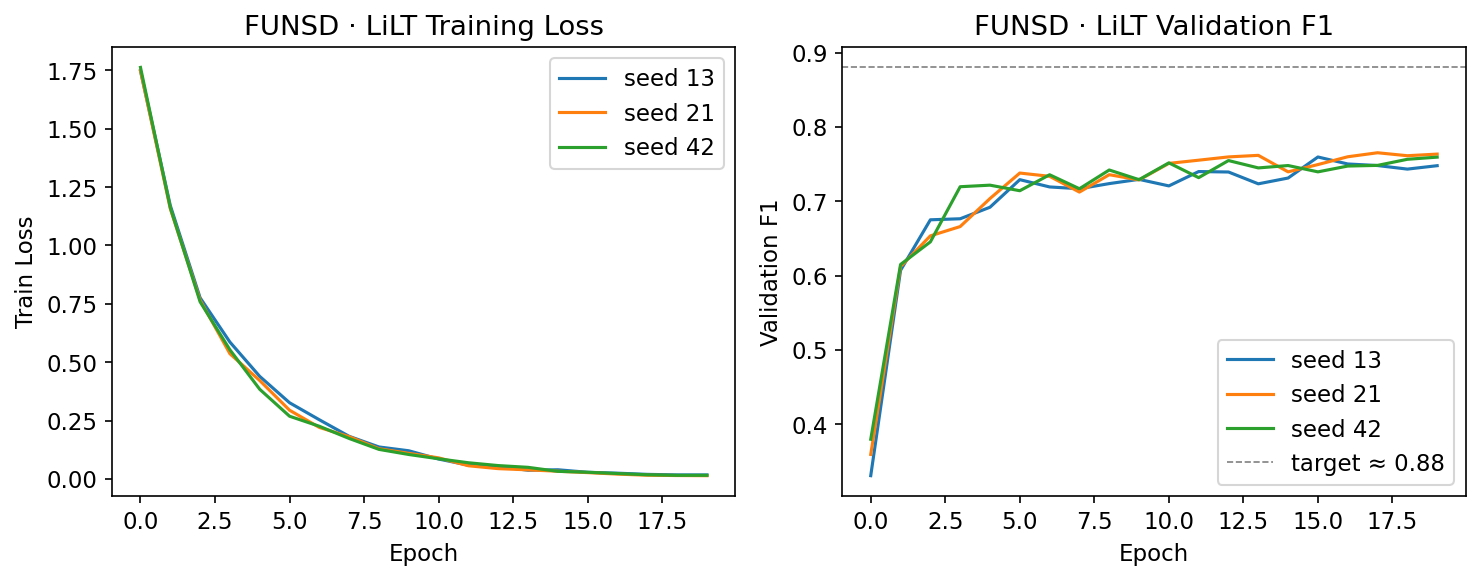

In [11]:
# ── Plot: FUNSD training curves ────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 11, "figure.dpi": 150})

if funsd_metrics_path.exists():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    for run in metrics["runs"]:
        epochs = [h["epoch"] for h in run["history"]]
        losses = [h["train_loss"] for h in run["history"]]
        val_f1s = [h["val_f1"] for h in run["history"]]

        ax1.plot(epochs, losses, label=f"seed {run['seed']}")
        ax2.plot(epochs, val_f1s, label=f"seed {run['seed']}")

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Train Loss")
    ax1.set_title("FUNSD · LiLT Training Loss")
    ax1.legend()

    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Validation F1")
    ax2.set_title("FUNSD · LiLT Validation F1")
    ax2.axhline(0.88, color="gray", linestyle="--", linewidth=0.8, label="target ≈ 0.88")
    ax2.legend()

    plt.tight_layout()
    fig.savefig("slides/figures/funsd_curve.pdf", bbox_inches="tight")
    print("Saved: slides/figures/funsd_curve.pdf")
    plt.show()
else:
    print("Skipping plot — no Track A metrics.")

---
## 3 · Track B — The Headline: VRDU MTL vs UTL Gap

**Purpose**: Measure the generalization gap with LiLT on VRDU Registration
Forms, leave-one-template-out, at matched 200-doc training size, ≥3 seeds.

**Calibration**: FormNet at 200 docs → MTL 90.51 vs UTL 77.29 (13.22-pt gap).

> This is the number that goes on the slide.  
> 3 templates → 3 UTL folds + 3 MTL folds, each with 3 seeds = 18 training runs.

In [12]:
# ── Run Track B ─────────────────────────────────────────────────────────
# Matched MTL/UTL protocol: 3 folds × 2 regimes × 3 seeds × 20 epochs.
# Expected wall time on P100: ~3–5 hrs.

!python src/train.py --config configs/vrdu_lilt.yaml --protocol matched

device: cuda  backbone: lilt  dataset: vrdu
VRDU: {"documents": 1915, "templates": {"Amendment": 709, "Dissemination_Report": 417, "Short-Form": 789}, "words": 1817007, "mean_words_per_doc": 948.8, "multi_page_docs": 1777, "docs_with_unaligned_entities": 0, "total_unaligned_entity_occurrences": 0}

LEAKAGE CHECK PASSED [MTL fold 0]
  template overlap is expected in MTL; checked document-level disjointness only
  shared templates train/test: ['Amendment', 'Dissemination_Report', 'Short-Form']
  no document id appears in more than one split

=== MTL/fold0/seed13 ===
[MTL] fold 0  held-out: (none)
  train:  200 docs over 3 templates ['Amendment', 'Dissemination_Report', 'Short-Form']
  val:    286 docs over 3 templates ['Amendment', 'Dissemination_Report', 'Short-Form']
  test:   381 docs over 3 templates ['Amendment', 'Dissemination_Report', 'Short-Form']
Loading weights: 100%|█| 398/398 [00:00<00:00, 1563.14it/s, Materializing param=
LiltForTokenClassification LOAD REPORT from: SCUT-DLV

In [13]:
# ── Inspect Track B results ─────────────────────────────────────────────
vrdu_metrics_path = Path("results/vrdu_lilt/metrics.json")

if vrdu_metrics_path.exists():
    vrdu_metrics = json.loads(vrdu_metrics_path.read_text())
    gap = vrdu_metrics["gap"]

    print("Track B — LiLT on VRDU Registration Forms")
    print(f"  MTL mean F1: {gap['mtl_mean_f1']:.4f} ± {gap['mtl_std']:.4f}  ({gap['mtl_folds']} runs)")
    print(f"  UTL mean F1: {gap['utl_mean_f1']:.4f} ± {gap['utl_std']:.4f}  ({gap['utl_folds']} runs)")
    print(f"  GAP (MTL - UTL): {gap['gap_f1']:.4f}  ({gap['relative_drop_pct']:.1f}% relative drop)")
    print(f"  FormNet calibration gap: 13.22 points")
    print()

    # Per-fold breakdown
    print("Per-run detail:")
    for regime in ("MTL", "UTL"):
        runs = vrdu_metrics[regime]
        print(f"\n  {regime}:")
        for r in runs:
            held = r.get("held_out", [])
            held_str = ", ".join(held) if held else "(all)"
            print(f"    fold={r['fold']} seed={r['seed']} F1={r['test']['f1']:.4f}  "
                  f"held_out=[{held_str}]")
else:
    print(f"No metrics at {vrdu_metrics_path} — did Track B run?")

Track B — LiLT on VRDU Registration Forms
  MTL mean F1: 0.8774 ± 0.0162  (9 runs)
  UTL mean F1: 0.6666 ± 0.0729  (9 runs)
  GAP (MTL - UTL): 0.2108  (24.0% relative drop)
  FormNet calibration gap: 13.22 points

Per-run detail:

  MTL:
    fold=0 seed=13 F1=0.8654  held_out=[(all)]
    fold=0 seed=21 F1=0.8649  held_out=[(all)]
    fold=0 seed=42 F1=0.8739  held_out=[(all)]
    fold=1 seed=13 F1=0.8623  held_out=[(all)]
    fold=1 seed=21 F1=0.8982  held_out=[(all)]
    fold=1 seed=42 F1=0.8598  held_out=[(all)]
    fold=2 seed=13 F1=0.8838  held_out=[(all)]
    fold=2 seed=21 F1=0.8839  held_out=[(all)]
    fold=2 seed=42 F1=0.9045  held_out=[(all)]

  UTL:
    fold=0 seed=13 F1=0.6712  held_out=[Amendment]
    fold=0 seed=21 F1=0.6569  held_out=[Amendment]
    fold=0 seed=42 F1=0.6466  held_out=[Amendment]
    fold=1 seed=13 F1=0.7404  held_out=[Dissemination_Report]
    fold=1 seed=21 F1=0.7151  held_out=[Dissemination_Report]
    fold=1 seed=42 F1=0.7876  held_out=[Dissemination_

Saved: slides/figures/vrdu_gap.pdf


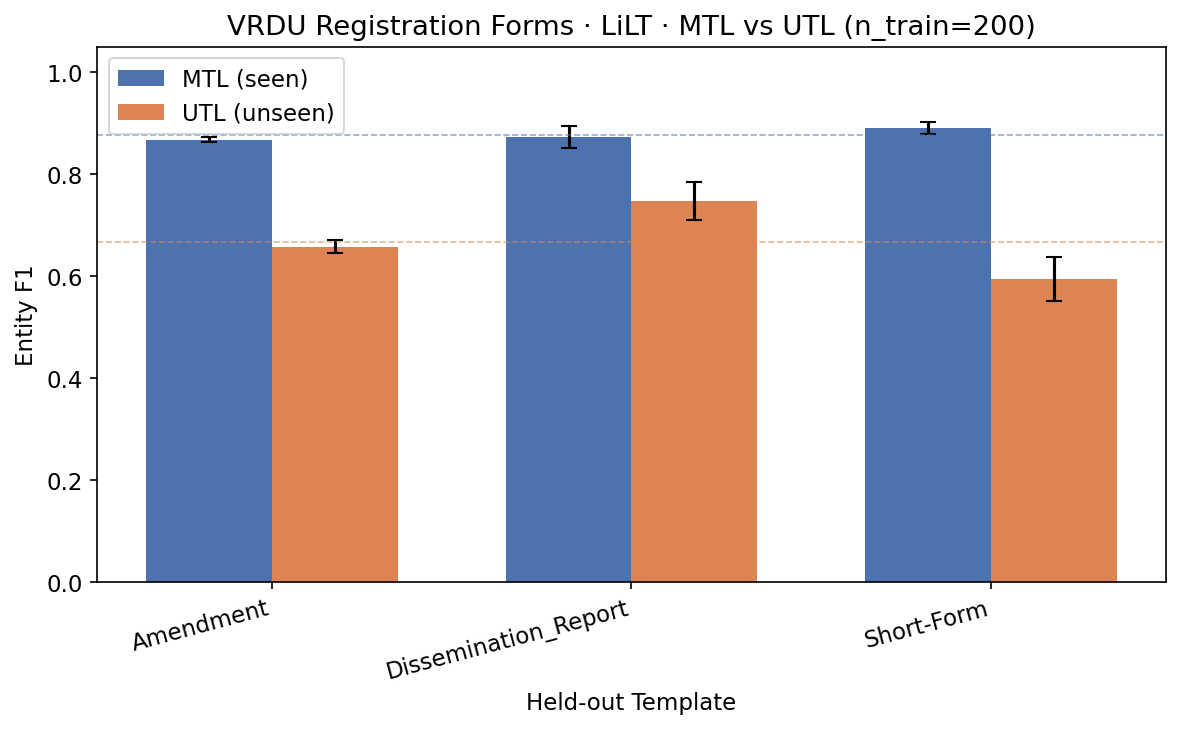

In [14]:
# ── Plot: VRDU MTL vs UTL per-template bar chart ────────────────────────
import numpy as np

if vrdu_metrics_path.exists():
    # Aggregate F1 per fold (template) and regime
    from collections import defaultdict

    fold_f1 = defaultdict(lambda: defaultdict(list))  # regime -> fold -> [f1s]
    fold_labels = {}  # fold -> held_out template name

    for regime in ("MTL", "UTL"):
        for r in vrdu_metrics[regime]:
            fold_f1[regime][r["fold"]].append(r["test"]["f1"])
            if r["fold"] not in fold_labels and r.get("held_out"):
                fold_labels[r["fold"]] = r["held_out"][0]

    folds = sorted(fold_f1["MTL"].keys())
    template_names = [fold_labels.get(f, f"Fold {f}") for f in folds]

    mtl_means = [np.mean(fold_f1["MTL"][f]) for f in folds]
    mtl_stds  = [np.std(fold_f1["MTL"][f], ddof=1) if len(fold_f1["MTL"][f]) > 1 else 0 for f in folds]
    utl_means = [np.mean(fold_f1["UTL"][f]) for f in folds]
    utl_stds  = [np.std(fold_f1["UTL"][f], ddof=1) if len(fold_f1["UTL"][f]) > 1 else 0 for f in folds]

    x = np.arange(len(folds))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    bars_mtl = ax.bar(x - width/2, mtl_means, width, yerr=mtl_stds,
                      label="MTL (seen)", color="#4C72B0", capsize=4)
    bars_utl = ax.bar(x + width/2, utl_means, width, yerr=utl_stds,
                      label="UTL (unseen)", color="#DD8452", capsize=4)

    ax.set_xlabel("Held-out Template")
    ax.set_ylabel("Entity F1")
    ax.set_title("VRDU Registration Forms · LiLT · MTL vs UTL (n_train=200)")
    ax.set_xticks(x)
    ax.set_xticklabels(template_names, rotation=15, ha="right")
    ax.legend()
    ax.set_ylim(0, 1.05)

    # Annotate the overall gap
    overall_gap = gap["gap_f1"]
    ax.axhline(gap["mtl_mean_f1"], color="#4C72B0", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.axhline(gap["utl_mean_f1"], color="#DD8452", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.annotate(f"Gap: {overall_gap:.2f}",
                xy=(len(folds) - 0.3, (gap["mtl_mean_f1"] + gap["utl_mean_f1"]) / 2),
                fontsize=12, fontweight="bold", color="#333333",
                ha="left", va="center")

    plt.tight_layout()
    fig.savefig("slides/figures/vrdu_gap.pdf", bbox_inches="tight")
    print("Saved: slides/figures/vrdu_gap.pdf")
    plt.show()
else:
    print("Skipping plot — no Track B metrics.")

---
## 4 · Error Analysis

Classify prediction errors into the four-bucket failure taxonomy:
1. OCR / recognition errors
2. Layout-association errors (right text, wrong key)
3. Field-type / schema errors
4. Repeated-structure errors

This runs on the Track B results (UTL condition — the unseen-template errors
are the ones that matter for the project's story).

In [16]:
# ── Error taxonomy on Track B UTL predictions ──────────────────────────
# Re-run inference on the best UTL checkpoint and classify errors.
# This requires the trained model state, so we re-load and predict.

from data.vrdu_loader import load_vrdu, load_splits, verify_template_recovery
from data.splits import matched_size_protocol, assert_no_template_leakage
from models.token_clf import TokenClassifier
from train import TrainConfig, set_seed, predict, FormDataset, make_collator, train_one
from evaluate import entity_f1
from errors import classify_errors, summarize_errors, error_table
from torch.utils.data import DataLoader

config = TrainConfig.from_yaml("configs/vrdu_lilt.yaml")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

examples, label_list, id2label = load_vrdu(Path(config.data_root), config.subcorpus)
protocol = matched_size_protocol(examples, n_train=config.n_train or 200, seed=config.seeds[0])

# Run error analysis on UTL folds only (the unseen-template condition)
all_preds, all_refs, all_words = [], [], []

for fold_idx, split in enumerate(protocol["UTL"]):
    print(f"\n--- UTL fold {fold_idx} (held-out: {split.held_out_templates}) ---")
    assert_no_template_leakage(split)

    seed = config.seeds[0]  # use first seed for error analysis
    set_seed(seed)

    classifier = TokenClassifier(config.backbone, len(label_list), id2label, config.max_length)
    result = train_one(classifier, split.train, split.val, split.test, config, device)
    print(f"  Test F1: {result['test']['f1']:.4f}")

    # Collect predictions for error analysis
    test_loader = DataLoader(
        FormDataset(split.test), batch_size=config.batch_size,
        collate_fn=make_collator(classifier),
    )
    preds, refs = predict(classifier, test_loader, device)
    words = [ex.words for ex in split.test]

    all_preds.extend(preds)
    all_refs.extend(refs)
    all_words.extend(words)

print(f"\nTotal test documents for error analysis: {len(all_preds)}")


--- UTL fold 0 (held-out: ('Amendment',)) ---


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

LiltForTokenClassification LOAD REPORT from: SCUT-DLVCLab/lilt-roberta-en-base
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight     | UNEXPECTED | 
pooler.dense.bias       | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  1/20:   0%|                                                | 0/50 [00:00<?, ?b/s]

Epoch  2/20:   0%|                                                | 0/50 [00:00<?, ?b/s]

...

Epoch 18/20:   0%|                                                | 0/50 [00:00<?, ?b/s]

Epoch 19/20:   0%|                                                | 0/50 [00:00<?, ?b/s]

Epoch 20/20:   0%|                                                | 0/50 [00:00<?, ?b/s]

Test eval:   0%|                                                | 0/198 [00:00<?, ?it/s]

  Test F1: 0.5891

Total test documents for error analysis: 1915


In [17]:
# ── Error taxonomy breakdown ────────────────────────────────────────────
breakdown = classify_errors(all_preds, all_refs, all_words, id2label)
print(summarize_errors(breakdown))

ERROR TAXONOMY BREAKDOWN
  TP: 1346  FP: 321  FN: 7483  total errors: 7804

  Ocr Recognition            FP:    0  FN:   14  total:   14  (  0.2%)
  Layout Association         FP:   39  FN:   49  total:   88  (  1.1%)
  Field Type Schema          FP:  189  FN: 7395  total: 7584  ( 97.2%)
  Repeated Structure         FP:   93  FN:   25  total:  118  (  1.5%)

  Ocr Recognition examples (up to 3):
    [FN] doc=42 type='file_date' [398:399] text='_'
          noise_score=1.00, fragmented=False

  Layout Association examples (up to 3):
    [FN] doc=4 type='foreign_principle_name' [84:88] text='Korea Trade Promotion Corporation'
          gold=foreign_principle_name, predicted_as=registrant_name
    [FP] doc=4 type='registrant_name' [84:85] text='Korea'
          predicted=registrant_name, gold=foreign_principle_name
    [FN] doc=8 type='foreign_principle_name' [95:99] text='Korea Trade Promotion Corporation'
          gold=foreign_principle_name, predicted_as=registrant_name

  Field Type 

            bucket  fp   fn  total  fraction
   Ocr Recognition   0   14     14    0.0018
Layout Association  39   49     88    0.0113
 Field Type Schema 189 7395   7584    0.9718
Repeated Structure  93   25    118    0.0151

Saved: slides/figures/error_taxonomy.pdf


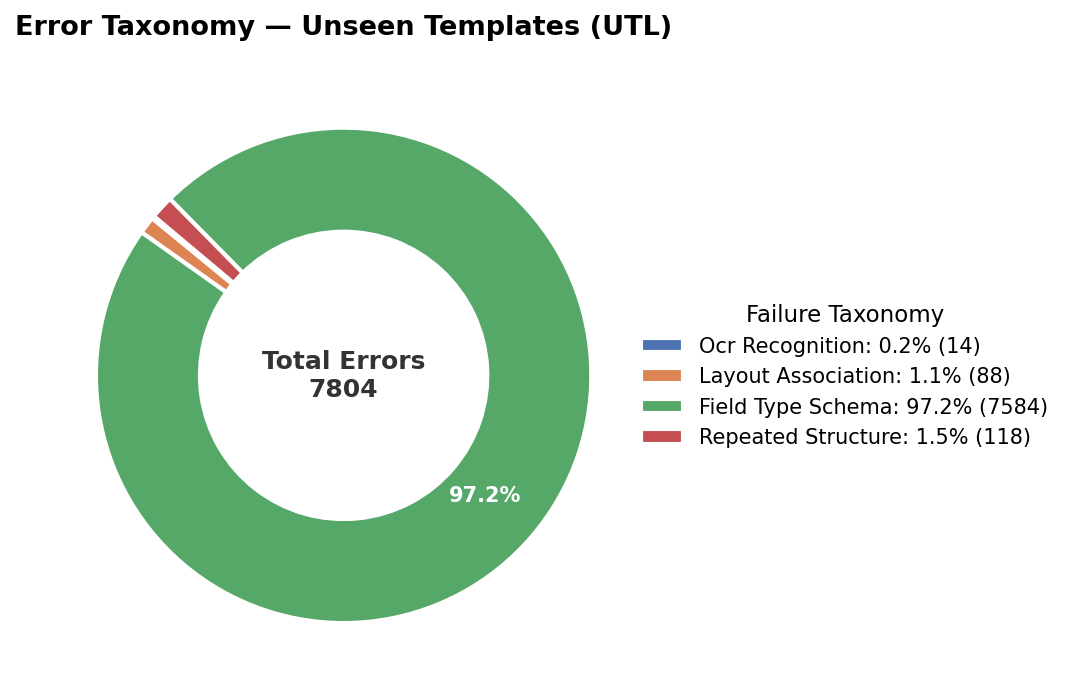

In [19]:
# ── Error taxonomy table & chart (for slides) ──────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.DataFrame(error_table(breakdown))
print(df.to_string(index=False))
print()

# Donut chart for slides (prevents label overlap for small slices)
fracs = breakdown.bucket_fractions()
bucket_counts = breakdown.bucket_counts()
labels = [k.replace("_", " ").title() for k in fracs]
sizes = [fracs[k] for k in fracs]
counts = [bucket_counts[k]["total"] for k in fracs]
palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

filtered = [(l, s, c, col) for l, s, c, col in zip(labels, sizes, counts, palette) if s > 0]
if filtered:
    labels_f, sizes_f, counts_f, colors_f = zip(*filtered)

    fig, ax = plt.subplots(figsize=(8, 4.8))

    # Clean donut ring with white borders
    wedges, texts, autotexts = ax.pie(
        sizes_f,
        colors=colors_f,
        autopct=lambda p: f"{p:.1f}%" if p >= 7.0 else "",
        pctdistance=0.75,
        startangle=140,
        wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
        textprops=dict(color="white", fontweight="bold", fontsize=10),
    )

    # Center headline: total error count
    ax.text(
        0, 0, f"Total Errors\n{breakdown.total_errors}",
        ha="center", va="center", fontsize=12, fontweight="bold", color="#333333"
    )

    # Side legend: clean, uncrowded, with counts & percentages
    legend_labels = [f"{l}: {s*100:.1f}% ({c})" for l, s, c in zip(labels_f, sizes_f, counts_f)]
    ax.legend(
        wedges,
        legend_labels,
        title="Failure Taxonomy",
        title_fontsize=11,
        loc="center left",
        bbox_to_anchor=(0.95, 0.5),
        frameon=False,
        fontsize=10,
    )

    ax.set_title("Error Taxonomy — Unseen Templates (UTL)", fontsize=13, fontweight="bold", pad=15)
    plt.tight_layout()
    fig.savefig("slides/figures/error_taxonomy.pdf", bbox_inches="tight")
    print("Saved: slides/figures/error_taxonomy.pdf")
    plt.show()
else:
    print("No errors to plot (perfect predictions).")

---
## 5 · Collect Outputs

Download these from the Kaggle notebook output:
- `results/funsd_lilt/metrics.json` — Track A numbers
- `results/vrdu_lilt/metrics.json` — Track B numbers + gap
- `slides/figures/funsd_curve.pdf` — training curves for slide 19
- `slides/figures/vrdu_gap.pdf` — MTL vs UTL bar chart for slide 20
- `slides/figures/error_taxonomy.pdf` — error breakdown for slide 21

In [20]:
# ── List all outputs ────────────────────────────────────────────────────
print("=== Generated files ===")
for pattern in ("results/**/*.json", "slides/figures/*.pdf"):
    for p in sorted(Path(".").glob(pattern)):
        print(f"  {p}  ({p.stat().st_size / 1024:.1f} KB)")

=== Generated files ===
  results/funsd_lilt/metrics.json  (9.5 KB)
  results/funsd_lilt/seed_13/best_meta.json  (0.1 KB)
  results/funsd_lilt/seed_13/history.json  (1.4 KB)
  results/funsd_lilt/seed_13/result.json  (2.5 KB)
  results/funsd_lilt/seed_21/best_meta.json  (0.1 KB)
  results/funsd_lilt/seed_21/history.json  (1.4 KB)
  results/funsd_lilt/seed_21/result.json  (2.5 KB)
  results/funsd_lilt/seed_42/best_meta.json  (0.1 KB)
  results/funsd_lilt/seed_42/history.json  (1.4 KB)
  results/funsd_lilt/seed_42/result.json  (2.5 KB)
  results/vrdu_lilt/MTL_fold0_seed13/best_meta.json  (0.1 KB)
  results/vrdu_lilt/MTL_fold0_seed13/history.json  (1.4 KB)
  results/vrdu_lilt/MTL_fold0_seed13/result.json  (2.9 KB)
  results/vrdu_lilt/MTL_fold0_seed21/best_meta.json  (0.1 KB)
  results/vrdu_lilt/MTL_fold0_seed21/history.json  (1.4 KB)
  results/vrdu_lilt/MTL_fold0_seed21/result.json  (2.9 KB)
  results/vrdu_lilt/MTL_fold0_seed42/best_meta.json  (0.1 KB)
  results/vrdu_lilt/MTL_fold0_seed42/

In [21]:
# ── Summary for the presentation ───────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY FOR SLIDES")
print("=" * 60)

if funsd_metrics_path.exists():
    m = json.loads(funsd_metrics_path.read_text())
    print(f"\nTrack A (pipeline check): LiLT on FUNSD")
    print(f"  F1 = {m['mean_f1']:.4f} ± {m['std_f1']:.4f}  (target ≈ 0.88)")

if vrdu_metrics_path.exists():
    m = json.loads(vrdu_metrics_path.read_text())
    g = m["gap"]
    print(f"\nTrack B (headline): LiLT on VRDU Registration Forms")
    print(f"  MTL (seen):   {g['mtl_mean_f1']:.4f} ± {g['mtl_std']:.4f}")
    print(f"  UTL (unseen): {g['utl_mean_f1']:.4f} ± {g['utl_std']:.4f}")
    print(f"  Gap:          {g['gap_f1']:.4f}  ({g['relative_drop_pct']:.1f}% drop)")
    print(f"  FormNet ref:  13.22 pt gap (MTL 90.51 / UTL 77.29)")

print("\n" + "=" * 60)


SUMMARY FOR SLIDES

Track A (pipeline check): LiLT on FUNSD
  F1 = 0.7929 ± 0.0136  (target ≈ 0.88)

Track B (headline): LiLT on VRDU Registration Forms
  MTL (seen):   0.8774 ± 0.0162
  UTL (unseen): 0.6666 ± 0.0729
  Gap:          0.2108  (24.0% drop)
  FormNet ref:  13.22 pt gap (MTL 90.51 / UTL 77.29)

